In [1]:
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load

# Download MNIST test split (10 000 images)
mnist_test = cast(Dataset, hf_load("ylecun/mnist", split="test"))

print(f"Downloaded {len(mnist_test)} MNIST test images")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded 10000 MNIST test images


In [2]:
import tempfile
from pathlib import Path

import numpy as np
from datamaite import load_ic

rng = np.random.default_rng(42)

# Per-class sample budgets — Facility C (digits 7–9) gets far fewer, and the
# collection never captured 8 or 9 at all.
samples_per_class = {
    0: 200,
    1: 200,
    2: 200,
    3: 200,  # Facility A — well-covered
    4: 120,
    5: 120,
    6: 120,  # Facility B — moderate
    7: 30,  # Facility C — under-represented
}

# Collect indices per class, then subsample
selected_indices: list[int] = []
labels_full = np.asarray(mnist_test["label"])

for cls, n in samples_per_class.items():
    cls_indices = np.where(labels_full == cls)[0]
    chosen = rng.choice(cls_indices, size=min(n, len(cls_indices)), replace=False)
    selected_indices.extend(chosen.tolist())

selected_indices.sort()

# Materialize the biased subset as an ImageFolder tree, then load it via datamaite
postal_root = Path(tempfile.mkdtemp(prefix="dataeval_flow_postal_"))
for seq, idx in enumerate(selected_indices):
    example = mnist_test[int(idx)]
    label_dir = postal_root / str(example["label"])
    label_dir.mkdir(parents=True, exist_ok=True)
    example["image"].save(label_dir / f"{seq:05d}.png")


# Two classes are plentiful by count but hollow in embedding space — the defects
# that per-class coverage catches and raw counts cannot.
#
#   digit 7 — every image is the same scanned card with tiny pixel jitter, so
#             almost the whole class sits in near-identical pairs. It also ends
#             up with the lowest dispersion, though (as we'll see) not low
#             enough to trip the default threshold.
#   digit 6 — 120 genuine images plus 60 copies of a single frame, so roughly a
#             third of the class is redundant.
def _jittered(frame: np.ndarray, count: int, rng: np.random.Generator) -> list[np.ndarray]:
    """`count` near-duplicate copies of one frame with tiny pixel jitter."""
    f = frame.astype(np.int16)
    return [np.clip(f + rng.integers(-3, 4, size=f.shape), 0, 255).astype(np.uint8) for _ in range(count)]


from PIL import Image

seven_dir = postal_root / "7"
seven_frame = np.asarray(Image.open(sorted(seven_dir.glob("*.png"))[0]))
for path in sorted(seven_dir.glob("*.png")):
    path.unlink()
for seq, arr in enumerate(_jittered(seven_frame, 30, rng)):
    Image.fromarray(arr).save(seven_dir / f"{seq:05d}.png")

six_dir = postal_root / "6"
six_frame = np.asarray(Image.open(sorted(six_dir.glob("*.png"))[0]))
for seq, arr in enumerate(_jittered(six_frame, 60, rng), start=10_000):
    Image.fromarray(arr).save(six_dir / f"{seq:05d}.png")

postal_maite = load_ic(postal_root, dataset_format="huggingface_vision")

# Computed from the materialized tree, not the collection budget above — that's
# the only way the count reflects digit 6's planted duplicates.
class_counts = {int(d.name): len(list(d.glob("*.png"))) for d in sorted(postal_root.iterdir())}

print(f"Selected {len(postal_maite)} images with biased class distribution")
print(f"Per-class counts: {class_counts}")

Selected 1250 images with biased class distribution
Per-class counts: {0: 200, 1: 200, 2: 200, 3: 200, 4: 120, 5: 120, 6: 180, 7: 30}


In [3]:
from collections.abc import Mapping
from typing import Any

from numpy.typing import NDArray


def digit_of(target: Any) -> int:
    """Recover the class index from a datamaite one-hot classification target."""
    t = np.asarray(target)
    return int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)


class BiasedMNIST:
    """Wraps a MAITE dataset with synthetic collection-condition metadata factors.

    Simulates a postal sorting system with uneven data collection across
    three facilities, each handling different digit classes under different
    lighting conditions.
    """

    def __init__(
        self,
        dataset: Any,
        rng: np.random.Generator,
    ) -> None:
        self._dataset = dataset

        # A MAITE `AnnotatedDataset` must expose a `metadata` mapping — dataeval
        # reads `index2label` from it to name classes in the report. Forward the
        # wrapped dataset's mapping rather than dropping it.
        self.metadata: dict[str, Any] = dict(dataset.metadata)

        # Pre-compute labels for metadata assignment
        self._labels = np.array([digit_of(dataset[i][1]) for i in range(len(dataset))])

        # Assign facility based on digit class
        self.facility = np.array(["A" if lbl <= 3 else "B" if lbl <= 6 else "C" for lbl in self._labels])

        # Assign lighting — dim is common for Facility A/B, rare for C
        self.lighting = np.empty(len(self._labels), dtype=object)
        for i, lbl in enumerate(self._labels):
            if lbl <= 6:
                # Facility A/B: 40% dim, 60% bright
                self.lighting[i] = rng.choice(["bright", "dim"], p=[0.6, 0.4])
            else:
                # Facility C: 95% bright, 5% dim — a metadata gap
                self.lighting[i] = rng.choice(["bright", "dim"], p=[0.95, 0.05])

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, sample_metadata = self._dataset[index]

        # Keep the loader's per-sample metadata (`id`, `height`, `width`) and add ours
        metadata: dict[str, Any] = {
            **dict(sample_metadata),
            "lighting": self.lighting[index],
            "facility": self.facility[index],
        }

        return np.asarray(image), target, metadata


biased_dataset = BiasedMNIST(postal_maite, rng)
print(f"BiasedMNIST: {len(biased_dataset)} samples")

# Spot-check metadata
for i in [0, 100, len(biased_dataset) - 1]:
    _, target, meta = biased_dataset[i]
    print(f"  Sample {i}: digit={digit_of(target)}, lighting={meta['lighting']}, facility={meta['facility']}")

BiasedMNIST: 1250 samples
  Sample 0: digit=0, lighting=bright, facility=A
  Sample 100: digit=0, lighting=bright, facility=A
  Sample 1249: digit=7, lighting=bright, facility=C


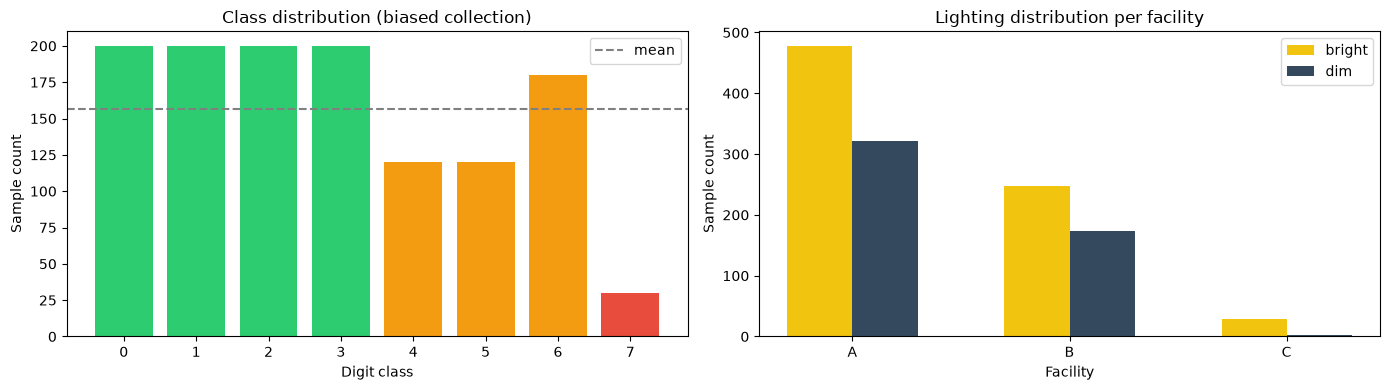

In [4]:
import matplotlib.pyplot as plt

# class_counts was computed from the materialized tree above, so digit 6's
# planted duplicates and digit 7's near-duplicate replacement both show up here.
ordered_classes = sorted(class_counts)  # range(8): digits 0-7
colors = ["#2ecc71"] * 4 + ["#f39c12"] * 3 + ["#e74c3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
ax1.bar([str(c) for c in ordered_classes], [class_counts[c] for c in ordered_classes], color=colors)
ax1.set_xlabel("Digit class")
ax1.set_ylabel("Sample count")
ax1.set_title("Class distribution (biased collection)")
ax1.axhline(y=np.mean(list(class_counts.values())), color="gray", linestyle="--", label="mean")
ax1.legend()

# Lighting distribution per facility
facilities = ["A", "B", "C"]
bright_counts = []
dim_counts = []
for fac in facilities:
    mask = biased_dataset.facility == fac
    bright_counts.append(int(np.sum(biased_dataset.lighting[mask] == "bright")))
    dim_counts.append(int(np.sum(biased_dataset.lighting[mask] == "dim")))

x = np.arange(len(facilities))
ax2.bar(x - 0.15, bright_counts, 0.3, label="bright", color="#f1c40f")
ax2.bar(x + 0.15, dim_counts, 0.3, label="dim", color="#34495e")
ax2.set_xticks(x)
ax2.set_xticklabels(facilities)
ax2.set_xlabel("Facility")
ax2.set_ylabel("Sample count")
ax2.set_title("Lighting distribution per facility")
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path

from dataeval_flow.config import PipelineConfig, SourceConfig
from dataeval_flow.config.schemas import (
    DataCoverageTaskConfig,
    DataCoverageWorkflowConfig,
    DatasetProtocolConfig,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.coverage.params import DataCoverageHealthThresholds

metadata_only_workflow = DataCoverageWorkflowConfig(
    name="coverage-metadata-only",
    # datamaite's loader attaches `id`, `height` and `width` to every sample.
    # `id` is unique per image (so it looks perfectly class-predictive) and the
    # two dimensions are constant here — exclude all three so the analysis sees
    # only the collection factors we care about.
    metadata_exclude=["id", "height", "width"],
    run_gap_analysis=True,
    # `lighting` only deviates for 1 of 8 classes (digit 7), so its class→factor
    # mutual information is small (~0.013). Keep the threshold below that or
    # the dim-lighting gap this tutorial is built around never gets
    # cross-tabulated.
    gap_mi_threshold=0.01,
    gap_min_representation=5,  # Flag class-factor-value combos with < 5 samples
    balance=True,
    diversity_method="simpson",
    health_thresholds=DataCoverageHealthThresholds(
        class_imbalance_ratio=3.0,  # Tight — we want to catch moderate imbalance
        gap_count=2,  # Warn if ≥ 2 gaps found
    ),
)

task_metadata = DataCoverageTaskConfig(
    name="postal-coverage-metadata",
    workflow="coverage-metadata-only",
    sources="postal_src",
    # No extractor — metadata-only pass
)

config_metadata = PipelineConfig(
    datasets=[
        DatasetProtocolConfig(name="postal_biased", format="maite", dataset=biased_dataset),
    ],
    sources=[
        SourceConfig(name="postal_src", dataset="postal_biased"),
    ],
    workflows=[metadata_only_workflow],
    tasks=[task_metadata],
)

In [6]:
result_metadata = run_task(task_metadata, config_metadata, cache_dir=Path("./cache"))

In [7]:
print(result_metadata.report())


  COVERAGE ANALYSIS: 1250 SAMPLES, 9 GAPS, DEFICIT=198.
  Timestamp:    2026-09-04T07:21:04.678567+00:00
  Duration:     0.09s
  Source:       postal_src (postal_biased)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Label Distribution ............................ 8 classes, ratio 6.7:1  [!!]
  Metadata Distribution 2 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................. 9 gaps identified  [!!]
  Class Balance Worklist ................. 3 classes short · deficit 198  [..]

  Health: 2 warning(s) [!!] — review flagged findings

  LABEL DISTRIBUTION                                      8 classes, ratio 6.7:1
  8 classes with imbalance ratio 6.7:1. 0 images have no labels.

  Class  Count      %
  -----  -----  -----
  0        200  16.0%
  1        200  16.0%
  2        200  16.0%
  3        200  16.0%
  6        180  14.4%
  4        120   9.6%
  5        120   9.6%
  7        

In [8]:
raw = result_metadata.data.raw

# Label distribution
ld = raw.label_distribution
print(f"Number of classes: {ld.num_classes}")
print(f"Empty images: {len(ld.empty_images)}")
print("\nClass distribution:")
for cls, count in sorted(ld.class_distribution.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cls}: {count}")

Number of classes: 8
Empty images: 0

Class distribution:
  0: 200
  1: 200
  2: 200
  3: 200
  6: 180
  4: 120
  5: 120
  7: 30


In [9]:
# Metadata gaps — the most actionable finding
if raw.metadata_gaps and raw.metadata_gaps.gaps:
    print("Metadata coverage gaps:")
    print(f"  Total gaps found: {len(raw.metadata_gaps.gaps)}\n")

    print("  Mutual information (class → factor):")
    for factor, mi in raw.metadata_gaps.mutual_info_class_to_factor.items():
        print(f"    {factor}: {mi:.4f}")

    print("\n  Gap details:")
    for gap in raw.metadata_gaps.gaps:
        print(
            f"    {gap.class_name} × {gap.factor_name}={gap.factor_value}: "
            f"count={gap.class_count}, expected={gap.expected_count:.1f}, "
            f"deficit={gap.deficit:.0%}"
        )
else:
    print("No metadata gaps detected.")

Metadata coverage gaps:
  Total gaps found: 9

  Mutual information (class → factor):
    facility: 0.3706
    lighting: 0.0031

  Gap details:
    0 × facility=B: count=0, expected=67.2, deficit=100%
    1 × facility=B: count=0, expected=67.2, deficit=100%
    2 × facility=B: count=0, expected=67.2, deficit=100%
    3 × facility=B: count=0, expected=67.2, deficit=100%
    4 × facility=A: count=0, expected=76.8, deficit=100%
    5 × facility=A: count=0, expected=76.8, deficit=100%
    6 × facility=A: count=0, expected=115.2, deficit=100%
    7 × facility=A: count=0, expected=19.2, deficit=100%
    7 × facility=B: count=0, expected=10.1, deficit=100%


In [10]:
import string

postal_ontology = {
    "postal_char": {
        "digit": {
            "low": [str(d) for d in range(5)],
            "high": [str(d) for d in range(5, 10)],
        },
        "letter": {
            "vowel": list("AEIOU"),
            "consonant": [c for c in string.ascii_uppercase if c not in "AEIOU"],
        },
    }
}

ontology_workflow = metadata_only_workflow.model_copy(
    update={"name": "coverage-ontology", "ontology": postal_ontology},
)

task_ontology = DataCoverageTaskConfig(
    name="postal-coverage-ontology",
    workflow="coverage-ontology",
    sources="postal_src",
)

config_ontology = PipelineConfig(
    datasets=config_metadata.datasets,
    sources=config_metadata.sources,
    workflows=[ontology_workflow],
    tasks=[task_ontology],
)

result_ontology = run_task(task_ontology, config_ontology, cache_dir=Path("./cache"))
print(result_ontology.report())


  COVERAGE ANALYSIS: 1250 SAMPLES, 9 GAPS, DEFICIT=985.
  Timestamp:    2026-09-04T07:21:04.779218+00:00
  Duration:     0.07s
  Source:       postal_src (postal_biased)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Label Distribution ............................ 8 classes, ratio 6.7:1  [!!]
  Metadata Distribution 2 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................. 9 gaps identified  [!!]
  Label Space Coverage leaf coverage 22.2% · 28 to acquire · deficit 985  [!!]
  Label Conformance ........................................... conforms  [ok]
  Ontology Structure ................... 43 concepts, 36 leaves, depth 3  [..]

  Health: 3 warning(s) [!!] — review flagged findings

  LABEL DISTRIBUTION                                      8 classes, ratio 6.7:1
  8 classes with imbalance ratio 6.7:1. 0 images have no labels.

  Class  Count      %
  -----  -----  -----
  0    

In [11]:
onto = result_ontology.data.raw.ontology
print(f"source: {onto.source} (synthesized={onto.synthesized})")
print(f"leaf coverage: {onto.representation.leaf_coverage:.0%}")
print(f"total deficit: {onto.representation.total_deficit} labels\n")

print("Dark branches — whole regions of the label space with nothing in them:")
for branch in onto.representation.dark_branches:
    print(f"  {branch.label}: {branch.leaves} leaf classes, zero examples")

print("\nTop of the collection worklist:")
for row in onto.representation.worklist[:6]:
    print(f"  {row.label:>10}  {row.action:<8} have {row.count:>3}, want {row.target:>3}")

source: inline (synthesized=False)
leaf coverage: 22%
total deficit: 985 labels

Dark branches — whole regions of the label space with nothing in them:
  letter: 26 leaf classes, zero examples

Top of the collection worklist:
           8  acquire  have   0, want  35
           9  acquire  have   0, want  35
           A  acquire  have   0, want  35
           B  acquire  have   0, want  35
           C  acquire  have   0, want  35
           D  acquire  have   0, want  35


In [12]:
from dataeval import Ontology
from dataeval.core import label_reconciliation

# The workflow builds this for you from the `ontology` field; here we construct
# the same object directly so we can reconcile an arbitrary label list against it.
ontology_obj = Ontology.from_hierarchy(postal_ontology)
check = label_reconciliation(["0", "1", "oh", "seven"], ontology_obj)
print("matched:  ", dict(check["matched"]))
print("unmatched:", list(check["unmatched"]))

matched:   {'0': '0', '1': '1'}
unmatched: ['oh', 'seven']


In [13]:
from dataeval.config import set_max_processes

from dataeval_flow.config import BoVWExtractorConfig

set_max_processes(8)

full_workflow = DataCoverageWorkflowConfig(
    name="coverage-full",
    metadata_exclude=["id", "height", "width"],
    coverage_method="adaptive",
    coverage_percent=0.01,  # adaptive: flag the sparsest 1% of observations
    num_observations=50,  # Number of neighbors for coverage analysis
    run_completeness=True,  # Measure dimensional completeness
    run_gap_analysis=True,
    gap_mi_threshold=0.01,  # lighting's MI is ~0.013 — see the note in Step 1
    balance=True,
    diversity_method="simpson",
    health_thresholds=DataCoverageHealthThresholds(
        uncovered_rate=10.0,  # Warn if > 10% uncovered in embedding space
        completeness_score=0.5,  # Warn if completeness < 0.5
        class_imbalance_ratio=3.0,  # Keep the tight threshold
        gap_count=2,
    ),
)

task_full = DataCoverageTaskConfig(
    name="postal-coverage-full",
    workflow="coverage-full",
    sources="postal_src",
    extractor="bovw_ext",
)

config_full = PipelineConfig(
    datasets=[
        DatasetProtocolConfig(name="postal_biased", format="maite", dataset=biased_dataset),
    ],
    sources=[
        SourceConfig(name="postal_src", dataset="postal_biased"),
    ],
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=256, batch_size=32),
    ],
    workflows=[full_workflow],
    tasks=[task_full],
)

In [14]:
result_full = run_task(task_full, config_full, cache_dir=Path("./cache"))

In [15]:
print(result_full.report())


  COVERAGE ANALYSIS: 1250 SAMPLES, 12 UNCOVERED, COMPLETENESS=0.01, 9 GAPS, DEFICIT=198.
  Timestamp:    2026-09-04T07:21:05.610071+00:00
  Duration:     0.80s
  Source:       postal_src (postal_biased)
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Embedding Coverage 12 uncovered (1.0%) · 1 clustered, 3 duplicate-padded  [!!]
  Dimensional Completeness ......................... Completeness: 0.013  [!!]
  Label Distribution ............................ 8 classes, ratio 6.7:1  [!!]
  Metadata Distribution 2 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................. 9 gaps identified  [!!]
  Class Balance Worklist ................. 3 classes short · deficit 198  [..]

  Health: 4 warning(s) [!!] — review flagged findings

  EMBEDDING COVERAGE       12 uncovered (1.0%) · 1 clustered, 3 duplicate-padded
  12 of 1250 images uncovered in embedding space. 

In [16]:
raw_full = result_full.data.raw

# Embedding coverage
if raw_full.coverage:
    cov = raw_full.coverage
    print(f"Method: {cov.method}")
    print(f"Uncovered: {cov.uncovered_count} ({cov.uncovered_rate:.1%})\n")
    print(f"{'class':>8}  {'count':>5}  {'disp':>6}  {'iso':>6}  {'nearDup':>7}")
    for row in cov.per_class:

        def _fmt(v: float | None) -> str:
            return "  -   " if v is None else f"{v:6.2f}"

        print(
            f"{row.class_name:>8}  {row.count:>5}  {_fmt(row.dispersion)}  {_fmt(row.isotropy)}  {_fmt(row.near_duplicate_fraction):>7}"
        )
elif raw_full.coverage_skipped_reason:
    print(f"Embedding coverage skipped: {raw_full.coverage_skipped_reason}")
else:
    print("No embedding coverage (extractor not configured)")

print()

# Dimensional completeness
if raw_full.completeness:
    comp = raw_full.completeness
    print("Dimensional Completeness:")
    print(f"  Score: {comp.completeness_score:.3f}")
    print(f"  Nearest neighbor pairs: {len(comp.nearest_neighbor_pairs)}")
else:
    print("No completeness data (extractor not configured)")

Method: adaptive
Uncovered: 12 (1.0%)

   class  count    disp     iso  nearDup
       7     30    0.26    -        0.89
       1    200    0.69    -        0.43
       6    180    0.91    -        0.37
       4    120    0.96    -        0.02
       2    200    1.04    -        0.02
       3    200    1.05    -        0.00
       5    120    1.07    -        0.01
       0    200    1.20    -        0.00

Dimensional Completeness:
  Score: 0.013
  Nearest neighbor pairs: 1177


In [17]:
strict_thresholds = DataCoverageHealthThresholds(
    uncovered_rate=5.0,
    completeness_score=0.6,
    class_imbalance_ratio=2.0,
    gap_count=1,
    min_dispersion=0.7,
    min_isotropy=0.7,
    max_near_duplicate_fraction=0.02,
    leaf_coverage=0.95,
    dark_branch_count=0,
    unmatched_class_count=0,
)

strict_workflow = full_workflow.model_copy(
    update={"name": "coverage-strict", "health_thresholds": strict_thresholds},
)

task_strict = DataCoverageTaskConfig(
    name="postal-coverage-strict",
    workflow="coverage-strict",
    sources="postal_src",
    extractor="bovw_ext",
)

config_strict = PipelineConfig(
    datasets=config_full.datasets,
    sources=config_full.sources,
    extractors=config_full.extractors,
    workflows=[full_workflow, strict_workflow],
    tasks=[task_strict],
)

result_strict = run_task(task_strict, config_strict, cache_dir=Path("./cache"))
print(result_strict.report())


  COVERAGE ANALYSIS: 1250 SAMPLES, 12 UNCOVERED, COMPLETENESS=0.01, 9 GAPS, DEFICIT=198.
  Timestamp:    2026-09-04T07:21:06.390158+00:00
  Duration:     0.75s
  Source:       postal_src (postal_biased)
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Embedding Coverage 12 uncovered (1.0%) · 2 clustered, 3 duplicate-padded  [!!]
  Dimensional Completeness ......................... Completeness: 0.013  [!!]
  Label Distribution ............................ 8 classes, ratio 6.7:1  [!!]
  Metadata Distribution 2 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................. 9 gaps identified  [!!]
  Class Balance Worklist ................. 3 classes short · deficit 198  [..]

  Health: 4 warning(s) [!!] — review flagged findings

  EMBEDDING COVERAGE       12 uncovered (1.0%) · 2 clustered, 3 duplicate-padded
  12 of 1250 images uncovered in embedding space. 

In [18]:
json_str = result_full.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 86271 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-04T07:21:05.610071Z",
    "dataset_id": "postal_biased",
    "label_source": "protocol",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": null,
    "source_descriptions": [
      "postal_src (postal_biased)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "postal_src",
          "dataset": "postal_biased",
          "dataset_config": {
            "name": "postal_bi
...
